Running Risk Parity backtest...
Running Time-Series Momentum backtest...
Plotting results...


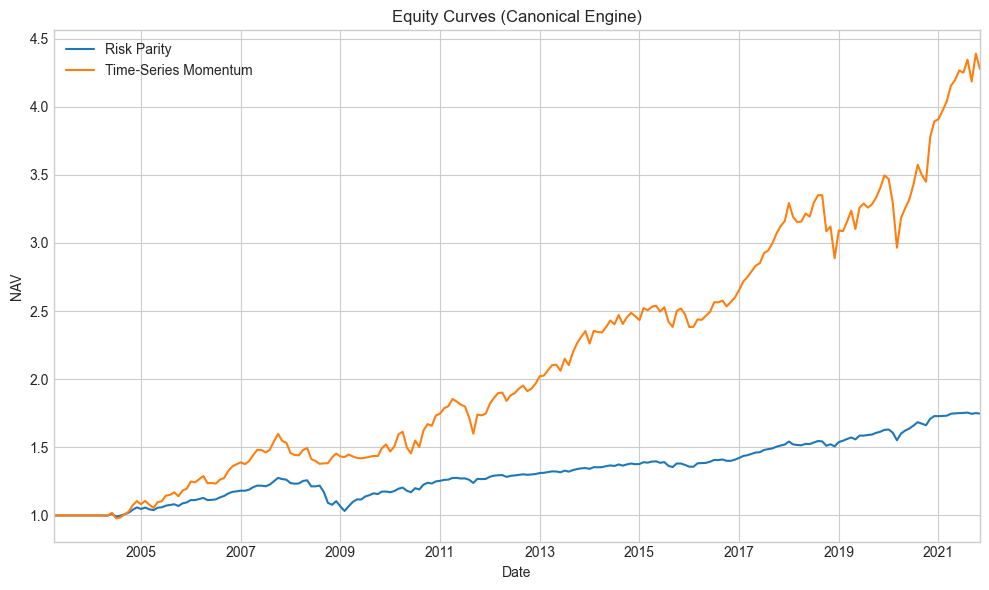

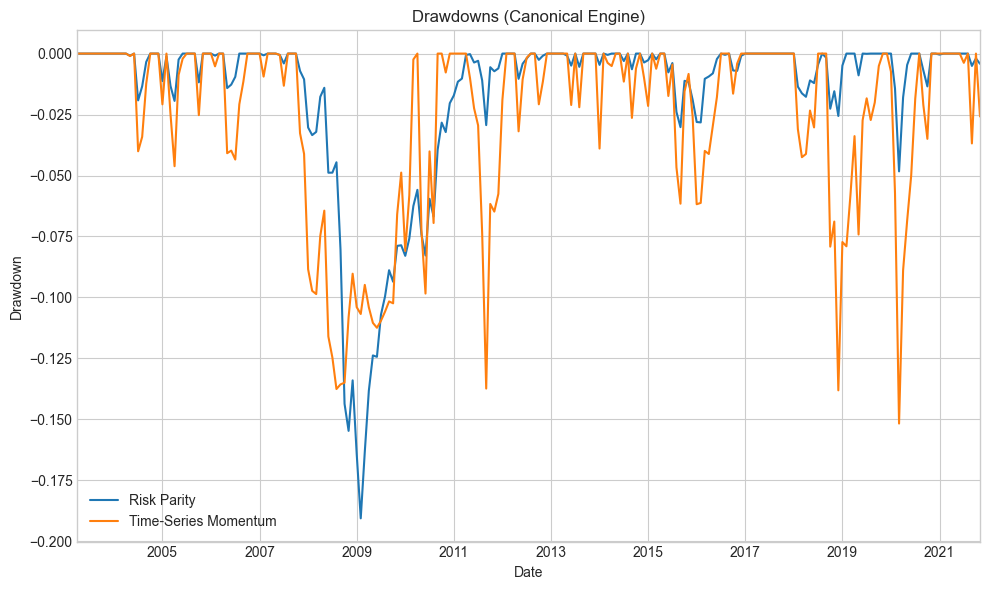

Done. Metrics file created: ../reports/tables/metrics.csv
      strategy    CAGR  Volatility  Sharpe  Sortino  MaxDrawdown  Turnover
0  risk_parity  0.0303      0.0415  0.7417   0.7566      -0.1906    0.3209
1  ts_momentum  0.0809      0.0961  0.8607   1.1320      -0.1517    2.0259


In [2]:
# === IMPORTS & CONFIG ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from functools import partial

# Allow imports from the src directory
if Path.cwd().name == "notebooks":
    sys.path.insert(0, str(Path.cwd().parent))
else:
    sys.path.insert(0, str(Path.cwd()))

from src.backtest.core import monthly_rebalance
from src.strategies.risk_parity import risk_parity_weights
from src.strategies.momentum import ts_momentum_weights
from src.metrics import cagr, annual_volatility, sharpe, sortino, max_drawdown, turnover

# --- Configuration ---
DATA_PATH = Path("../data/prices_monthly.csv")
FIG_DIR = Path("../reports/figures")
TABLE_DIR = Path("../reports/tables")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Backtest parameters from config/backtest.yaml
COST_BPS = 10
MAX_WEIGHT = 0.35
LOOKBACK_RP = 12
LOOKBACK_MOM = 12

# === LOAD DATA ===
prices = pd.read_csv(DATA_PATH, parse_dates=["date"]).set_index("date").sort_index()

# === DEFINE STRATEGY FUNCTIONS (with lookback parameters) ===
# Use functools.partial to create functions that match the engine's expected signature
weight_func_rp = partial(risk_parity_weights, window_months=LOOKBACK_RP)
weight_func_mom = partial(ts_momentum_weights, lookback_months=LOOKBACK_MOM)

# === RUN BACKTESTS USING CANONICAL ENGINE ===
print("Running Risk Parity backtest...")
nav_rp, weights_rp, _ = monthly_rebalance(prices, weight_func_rp, max_weight=MAX_WEIGHT, cost_bps=COST_BPS)

print("Running Time-Series Momentum backtest...")
nav_mom, weights_mom, _ = monthly_rebalance(prices, weight_func_mom, max_weight=MAX_WEIGHT, cost_bps=COST_BPS)

# === CALCULATE METRICS USING CANONICAL FUNCTIONS ===
def evaluate(nav, weights, strategy_name):
    returns = nav.pct_change().fillna(0.0)
    return {
        "strategy": strategy_name,
        "CAGR": cagr(nav),
        "Volatility": annual_volatility(returns),
        "Sharpe": sharpe(returns),
        "Sortino": sortino(returns),
        "MaxDrawdown": max_drawdown(nav),
        "Turnover": turnover(weights)
    }

metrics_rp = evaluate(nav_rp, weights_rp, "risk_parity")
metrics_mom = evaluate(nav_mom, weights_mom, "ts_momentum")

# === SAVE ARTIFACTS ===
# Overwrite the metrics file to ensure it's clean
out_metrics = TABLE_DIR / "metrics.csv"
metrics_df = pd.DataFrame([metrics_rp, metrics_mom])
metrics_df.to_csv(out_metrics, index=False)

weights_rp.to_csv(TABLE_DIR / "weights_risk_parity.csv")
weights_mom.to_csv(TABLE_DIR / "weights_momentum.csv")

# === PLOTTING (No changes needed here) ===
print("Plotting results...")
plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(10, 6))
nav_rp.rename("Risk Parity").plot(legend=True)
nav_mom.rename("Time-Series Momentum").plot(legend=True)
plt.title("Equity Curves (Canonical Engine)")
plt.xlabel("Date"); plt.ylabel("NAV")
plt.tight_layout()
plt.savefig(FIG_DIR / "equity_compare.png", dpi=160)
plt.show()

plt.figure(figsize=(10, 6))
(nav_rp / nav_rp.cummax() - 1).rename("Risk Parity").plot(legend=True)
(nav_mom / nav_mom.cummax() - 1).rename("Time-Series Momentum").plot(legend=True)
plt.title("Drawdowns (Canonical Engine)")
plt.xlabel("Date"); plt.ylabel("Drawdown")
plt.tight_layout()
plt.savefig(FIG_DIR / "drawdown_compare.png", dpi=160)
plt.show()

print("Done. Metrics file created:", out_metrics)
print(metrics_df.round(4))

Running cost sensitivity analysis...
  Cost = 0 bps
  Cost = 10 bps
  Cost = 20 bps

Saved sensitivity results to: ../reports/tables/sensitivity_costs.csv


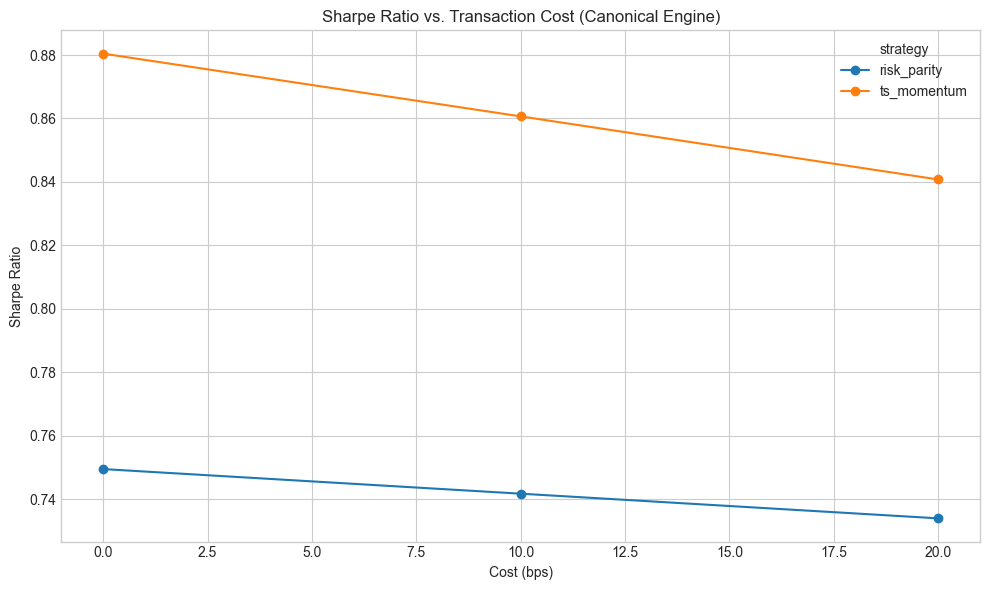

In [3]:
# === IMPORTS & CONFIG (if running cell independently) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from functools import partial

# Allow imports from the src directory
if Path.cwd().name == "notebooks":
    sys.path.insert(0, str(Path.cwd().parent))
else:
    sys.path.insert(0, str(Path.cwd()))

from src.backtest.core import monthly_rebalance
from src.strategies.risk_parity import risk_parity_weights
from src.strategies.momentum import ts_momentum_weights
from src.metrics import cagr, annual_volatility, sharpe, max_drawdown

# --- Configuration ---
DATA_PATH = Path("../data/prices_monthly.csv")
FIG_DIR = Path("../reports/figures")
TABLE_DIR = Path("../reports/tables")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MAX_WEIGHT = 0.35
LOOKBACK_RP = 12
LOOKBACK_MOM = 12

# === LOAD DATA ===
prices = pd.read_csv(DATA_PATH, parse_dates=["date"]).set_index("date").sort_index()

# === DEFINE STRATEGY FUNCTIONS ===
weight_func_rp = partial(risk_parity_weights, window_months=LOOKBACK_RP)
weight_func_mom = partial(ts_momentum_weights, lookback_months=LOOKBACK_MOM)

# === RUN SENSITIVITY ANALYSIS ===
results = []
cost_grid = [0, 10, 20] # bps

print("Running cost sensitivity analysis...")
for cost in cost_grid:
    print(f"  Cost = {cost} bps")
    # Run Risk Parity
    nav_rp, _, _ = monthly_rebalance(prices, weight_func_rp, max_weight=MAX_WEIGHT, cost_bps=cost)
    returns_rp = nav_rp.pct_change().fillna(0.0)
    results.append({
        "strategy": "risk_parity",
        "cost_bps": cost,
        "Sharpe": sharpe(returns_rp)
    })
    
    # Run Momentum
    nav_mom, _, _ = monthly_rebalance(prices, weight_func_mom, max_weight=MAX_WEIGHT, cost_bps=cost)
    returns_mom = nav_mom.pct_change().fillna(0.0)
    results.append({
        "strategy": "ts_momentum",
        "cost_bps": cost,
        "Sharpe": sharpe(returns_mom)
    })

# === SAVE & PLOT ===
df = pd.DataFrame(results)
out = TABLE_DIR / "sensitivity_costs.csv"
df.to_csv(out, index=False)
print("\nSaved sensitivity results to:", out)

plt.style.use("seaborn-v0_8-whitegrid")
ax = df.pivot(index="cost_bps", columns="strategy", values="Sharpe").plot(marker="o", figsize=(10, 6))
ax.set_title("Sharpe Ratio vs. Transaction Cost (Canonical Engine)")
ax.set_xlabel("Cost (bps)")
ax.set_ylabel("Sharpe Ratio")
plt.tight_layout()
plt.savefig(FIG_DIR / "sensitivity_sharpe.png", dpi=160)
plt.show()